Loaded parameters for synthetic modeling:
log_amp: -5.622911744390352
age_exp: -0.41111783044221895
mass_exp: 1.136548621136587
mu: -5.6229117444200165
sigma: 0.5413116880493393
age_range: [np.float64(5.01), np.float64(7.78)]
mass_range: [np.float64(0.1490000039339065), np.float64(1.991)]
logMstar_range: [np.float64(-0.8268137201214584), np.float64(0.2990712600274096)]
Generated synthetic cluster with 578 stars


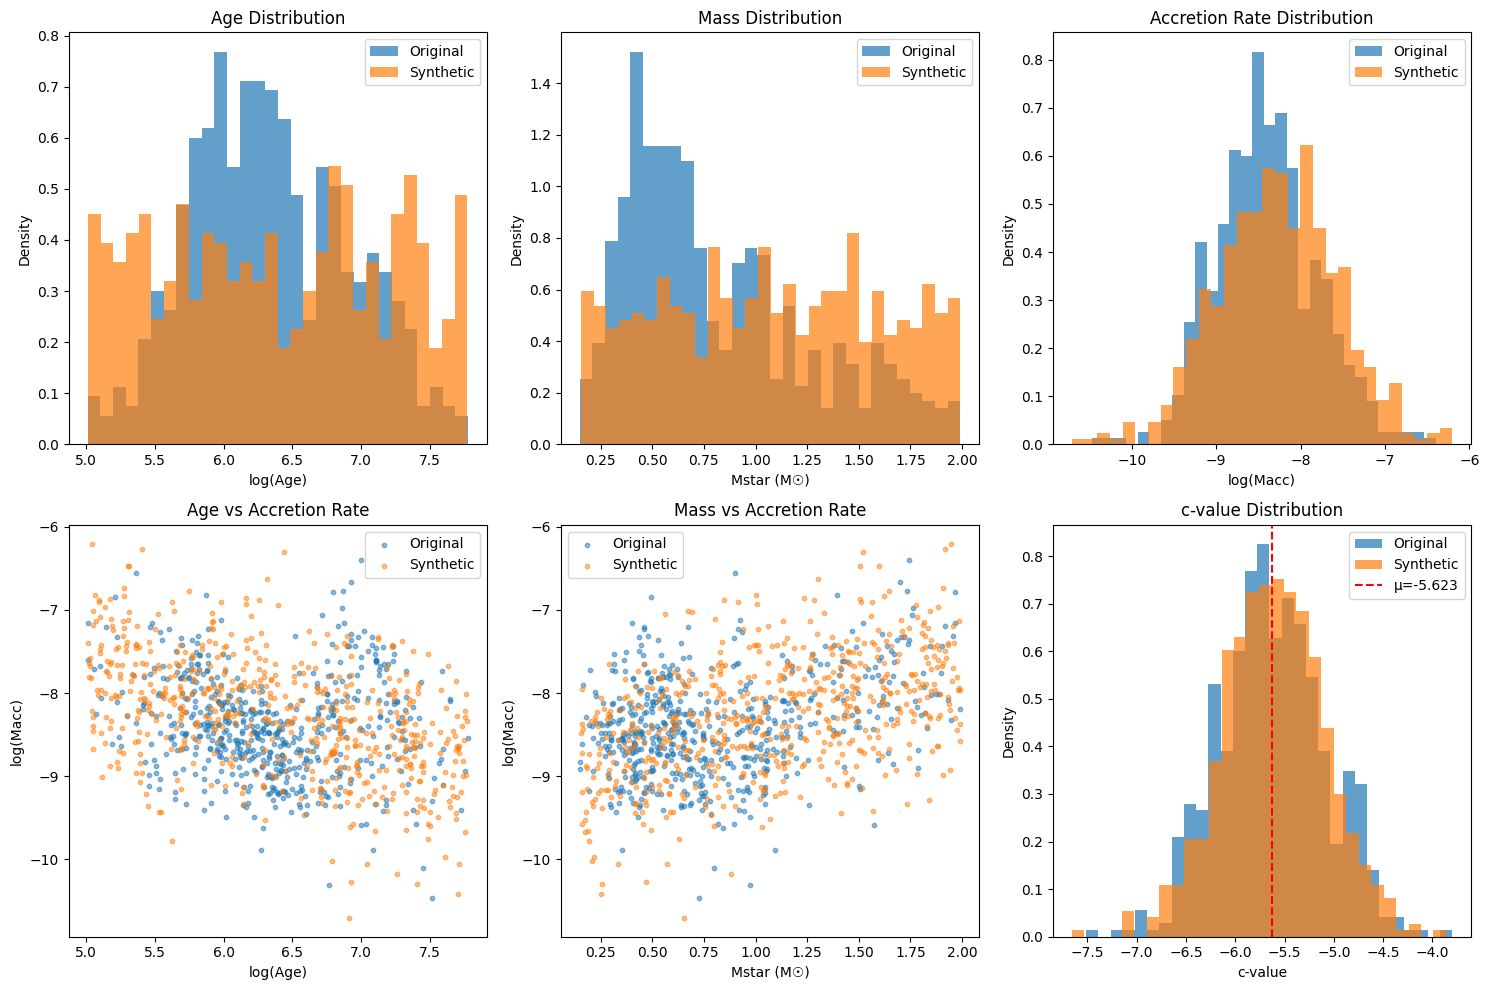

Statistical comparison between original and synthetic data:
logAge          KS statistic: 0.152, p-value: 0.000
Mstar           KS statistic: 0.266, p-value: 0.000
logMacc         KS statistic: 0.156, p-value: 0.000
c-values        KS statistic: 0.040, p-value: 0.750
✓ Synthetic cluster data saved to 'synthetic_stellar_cluster.csv'

Synthetic stellar mass percentiles for visualization:
10th percentile: 0.353 M☉
25th percentile: 0.626 M☉
Median: 1.069 M☉
75th percentile: 1.499 M☉
90th percentile: 1.816 M☉
macc_fit range - 10th %ile: 4.654e-10 to 6.351e-09
macc_fit range - 25th %ile: 8.906e-10 to 1.215e-08
macc_fit range - Median: 1.638e-09 to 2.234e-08
macc_fit range - 75th %ile: 2.403e-09 to 3.280e-08
macc_fit range - 90th %ile: 2.990e-09 to 4.080e-08

Rolling median calculated with window size: 28 points
✓ Synthetic cluster plot saved as 'synthetic_power_law_validation.png'


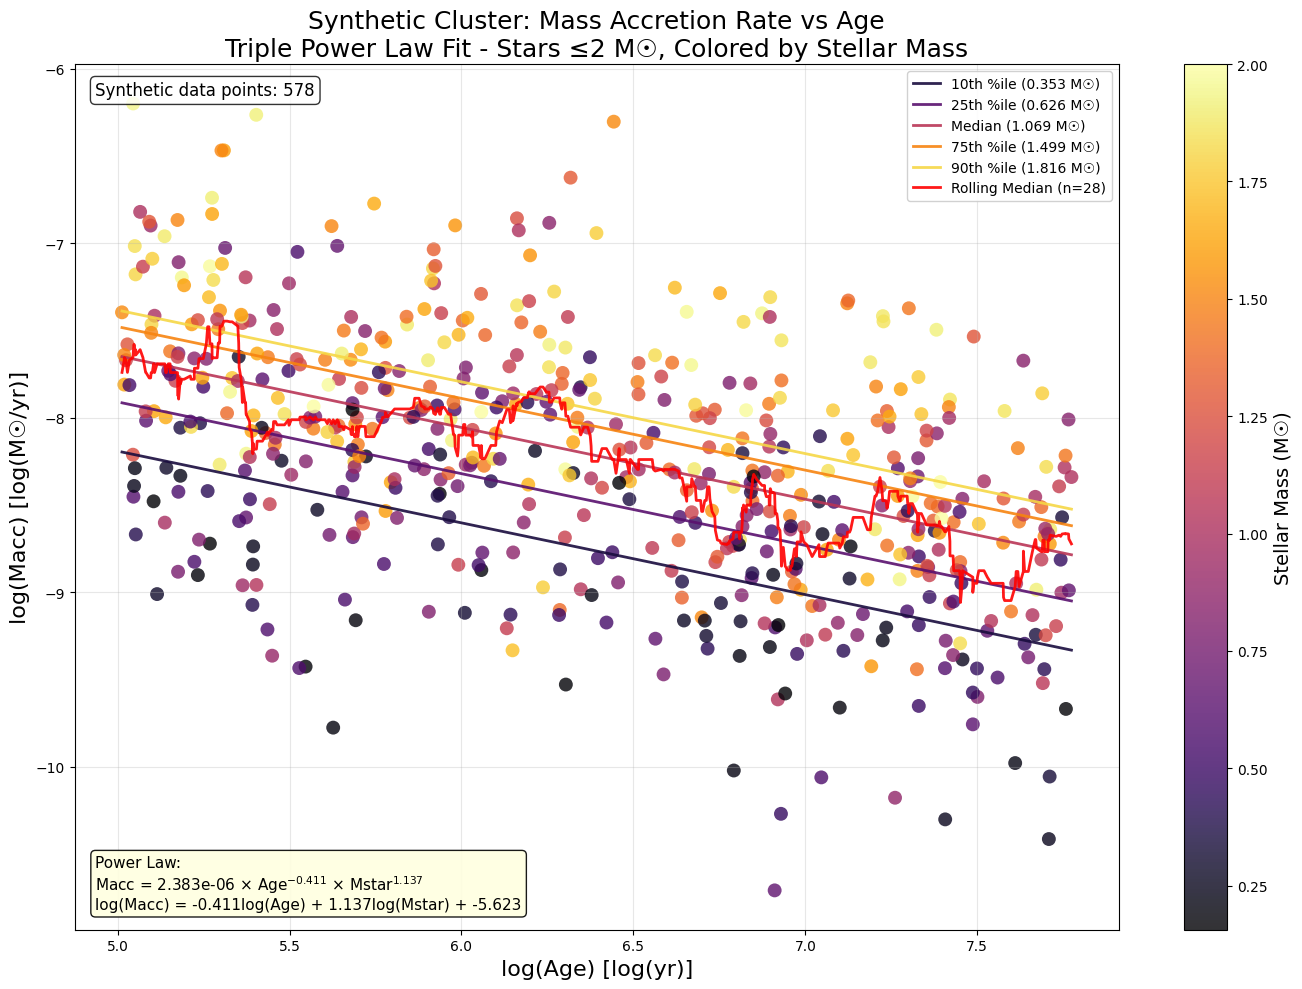

✓ Complete synthetic analysis saved as: Synthetic_Cluster_Validation_Report.pdf


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.special import erfinv
from scipy.stats import ks_2samp
from matplotlib.backends.backend_pdf import PdfPages

# Load pre-computed parameters - using new file names
params = np.load('power_law_model.npy', allow_pickle=True).item()
df_original = pd.read_csv('stellar_accretion_data.csv')

print("Loaded parameters for synthetic modeling:")
for key, value in params.items():
    if key not in ['original_fit_params']: 
        print(f"{key}: {value}")

# ============================================================================
# GENERATE SYNTHETIC CLUSTER AND GAUSSIAN DISTRUBUTION FUNCTION
# ============================================================================

# Gaussian distribution function
def Gaussian_dist(mu, sigma, points):
    x = np.zeros(points)
    for i in range(points):
        x[i] = mu + sigma * np.sqrt(2) * erfinv(2 * random.uniform(0, 1) - 1)
    return np.array(x)

# Generate synthetic cluster - CORRECTED VERSION
def generate_synthetic_cluster(n_stars=578):
    # Generate random ages and masses within observed ranges
    synthetic_ages = np.random.uniform(params['age_range'][0], params['age_range'][1], n_stars)
    synthetic_masses = np.random.uniform(params['mass_range'][0], params['mass_range'][1], n_stars)
    synthetic_logMstar = np.log10(synthetic_masses)
    
    # CORRECTION: Deterministic part WITHOUT log_amp (mean comes from c distribution)
    logMacc_deterministic = (params['age_exp'] * synthetic_ages + 
                           params['mass_exp'] * synthetic_logMstar)
    
    # CORRECTION: c-values include the mean offset μ
    c_values = Gaussian_dist(params['mu'], params['sigma'], n_stars)
    synthetic_logMacc = logMacc_deterministic + c_values
    
    # Create synthetic dataframe
    synthetic_df = pd.DataFrame({
        'logAge': synthetic_ages,
        'Mstar': synthetic_masses,
        'logMstar': synthetic_logMstar,
        'logMacc': synthetic_logMacc,
        'logMacc_deterministic': logMacc_deterministic + params['mu'],  # For comparison
        'c_value': c_values,
        'is_synthetic': True
    })
    
    return synthetic_df

# Generate synthetic data
synthetic_df = generate_synthetic_cluster(len(df_original))
print(f"Generated synthetic cluster with {len(synthetic_df)} stars")

# ============================================================================
# COMPARE SYNTHETIC AND REAL DATA
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Age distribution
axes[0,0].hist(df_original['logAge'], bins=30, alpha=0.7, label='Original', density=True)
axes[0,0].hist(synthetic_df['logAge'], bins=30, alpha=0.7, label='Synthetic', density=True)
axes[0,0].set_xlabel('log(Age)')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Age Distribution')
axes[0,0].legend()

# Plot 2: Mass distribution
axes[0,1].hist(df_original['Mstar'], bins=30, alpha=0.7, label='Original', density=True)
axes[0,1].hist(synthetic_df['Mstar'], bins=30, alpha=0.7, label='Synthetic', density=True)
axes[0,1].set_xlabel('Mstar (M☉)')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Mass Distribution')
axes[0,1].legend()

# Plot 3: Accretion rate distribution
axes[0,2].hist(df_original['logMacc'], bins=30, alpha=0.7, label='Original', density=True)
axes[0,2].hist(synthetic_df['logMacc'], bins=30, alpha=0.7, label='Synthetic', density=True)
axes[0,2].set_xlabel('log(Macc)')
axes[0,2].set_ylabel('Density')
axes[0,2].set_title('Accretion Rate Distribution')
axes[0,2].legend()

# Plot 4: Age vs Macc comparison
axes[1,0].scatter(df_original['logAge'], df_original['logMacc'], alpha=0.5, label='Original', s=10)
axes[1,0].scatter(synthetic_df['logAge'], synthetic_df['logMacc'], alpha=0.5, label='Synthetic', s=10)
axes[1,0].set_xlabel('log(Age)')
axes[1,0].set_ylabel('log(Macc)')
axes[1,0].set_title('Age vs Accretion Rate')
axes[1,0].legend()

# Plot 5: Mass vs Macc comparison
axes[1,1].scatter(df_original['Mstar'], df_original['logMacc'], alpha=0.5, label='Original', s=10)
axes[1,1].scatter(synthetic_df['Mstar'], synthetic_df['logMacc'], alpha=0.5, label='Synthetic', s=10)
axes[1,1].set_xlabel('Mstar (M☉)')
axes[1,1].set_ylabel('log(Macc)')
axes[1,1].set_title('Mass vs Accretion Rate')
axes[1,1].legend()

# Plot 6: c-value distribution comparison
# CORRECTION: Use the same formula for original c-values
original_c = df_original['logMacc'] - (params['age_exp'] * df_original['logAge'] + params['mass_exp'] * df_original['logMstar'])
axes[1,2].hist(original_c, bins=30, alpha=0.7, label='Original', density=True)
axes[1,2].hist(synthetic_df['c_value'], bins=30, alpha=0.7, label='Synthetic', density=True)
axes[1,2].axvline(params['mu'], color='red', linestyle='--', label=f'μ={params["mu"]:.3f}')
axes[1,2].set_xlabel('c-value')
axes[1,2].set_ylabel('Density')
axes[1,2].set_title('c-value Distribution')
axes[1,2].legend()

plt.tight_layout()
plt.show()

# Statistical comparison
print("Statistical comparison between original and synthetic data:")
comparisons = [
    ('logAge', df_original['logAge'], synthetic_df['logAge']),
    ('Mstar', df_original['Mstar'], synthetic_df['Mstar']),
    ('logMacc', df_original['logMacc'], synthetic_df['logMacc']),
    ('c-values', original_c, synthetic_df['c_value'])
]

for name, orig, synth in comparisons:
    ks_stat, p_value = ks_2samp(orig, synth)
    print(f"{name:15} KS statistic: {ks_stat:.3f}, p-value: {p_value:.3f}")

# Save synthetic data with better name
synthetic_df.to_csv('synthetic_stellar_cluster.csv', index=False)
print("✓ Synthetic cluster data saved to 'synthetic_stellar_cluster.csv'")

# ============================================================================
# USE SYNTHETIC DATA TO CREATE TRIPLE POWER LAW PLOT
# ============================================================================

fig_synth, ax_synth = plt.subplots(1, 1, figsize=(14, 10))

# Set up color scaling for synthetic data
vmax = 2.0 
vmin = synthetic_df['Mstar'].min()

# Plot synthetic data points colored by stellar mass
scatter_synth = ax_synth.scatter(synthetic_df['logAge'], synthetic_df['logMacc'], 
                                c=synthetic_df['Mstar'],
                                cmap='inferno',
                                vmin=vmin, vmax=vmax,
                                marker='o', 
                                edgecolors='none',
                                alpha=0.8, 
                                s=100)

# Add colorbar to show the Mstar scale
cbar_synth = plt.colorbar(scatter_synth, ax=ax_synth)
cbar_synth.set_label('Stellar Mass (M☉)', fontsize=14)

# Calculate percentile masses for synthetic data
mstar_10 = synthetic_df['Mstar'].quantile(0.10)
mstar_25 = synthetic_df['Mstar'].quantile(0.25)
mstar_median = synthetic_df['Mstar'].quantile(0.50)
mstar_75 = synthetic_df['Mstar'].quantile(0.75)
mstar_90 = synthetic_df['Mstar'].quantile(0.90)

print(f"\nSynthetic stellar mass percentiles for visualization:")
print(f"10th percentile: {mstar_10:.3f} M☉")
print(f"25th percentile: {mstar_25:.3f} M☉")
print(f"Median: {mstar_median:.3f} M☉")
print(f"75th percentile: {mstar_75:.3f} M☉")
print(f"90th percentile: {mstar_90:.3f} M☉")

# Generate fit line for all mass percentiles
x_fit_log = np.linspace(synthetic_df['logAge'].min(), synthetic_df['logAge'].max(), 100)
age_fit_linear = 10**x_fit_log

# Calculate triple power law predictions for each mass percentile
# CORRECTION: Include log_amp (which equals mu) in the prediction
mstar_percentiles = [mstar_10, mstar_25, mstar_median, mstar_75, mstar_90]
labels = ['10th %ile', '25th %ile', 'Median', '75th %ile', '90th %ile']

# Get colors from the colormap for each mass
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.inferno
colors = [cmap(norm(mstar)) for mstar in mstar_percentiles]

# Plot all fit lines with colors matching the colormap
for i, (mstar, color, label) in enumerate(zip(mstar_percentiles, colors, labels)):
    macc_fit = (10**params['log_amp']) * np.power(age_fit_linear, params['age_exp']) * np.power(mstar, params['mass_exp'])
    
    # Safety check for log10
    if np.any(macc_fit <= 0):
        macc_fit = np.maximum(macc_fit, 1e-10)
    
    ax_synth.plot(x_fit_log, np.log10(macc_fit), color=color, linewidth=2, 
            linestyle='-', alpha=0.9, label=f'{label} ({mstar:.3f} M☉)')
    
    print(f"macc_fit range - {label}: {macc_fit.min():.3e} to {macc_fit.max():.3e}")

# Rolling median calculation and plotting for synthetic data
synth_sorted = synthetic_df.sort_values('logAge').copy()

# Calculate rolling median
window_size = int(len(synthetic_df) * 0.05)
if window_size < 5:
    window_size = 5 
synth_sorted['rolling_median_logMacc'] = synth_sorted['logMacc'].rolling(window=window_size, center=True, min_periods=1).median()

# Plot rolling median
ax_synth.plot(synth_sorted['logAge'], synth_sorted['rolling_median_logMacc'], 
        color='red', linewidth=2, linestyle='-', alpha=0.9,
        label=f'Rolling Median (n={window_size})')

print(f"\nRolling median calculated with window size: {window_size} points")

# Configure plot appearance
ax_synth.set_xlabel('log(Age) [log(yr)]', fontsize=16)
ax_synth.set_ylabel('log(Macc) [log(M☉/yr)]', fontsize=16)
ax_synth.set_title('Synthetic Cluster: Mass Accretion Rate vs Age\nTriple Power Law Fit - Stars ≤2 M☉, Colored by Stellar Mass', fontsize=18)
ax_synth.grid(True, alpha=0.3)

# Add statistics to plot - TOP LEFT
stats_text = f'Synthetic data points: {len(synthetic_df)}'
ax_synth.text(0.02, 0.98, stats_text, transform=ax_synth.transAxes, 
        verticalalignment='top', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ADD EQUATIONS - BOTTOM LEFT
eq_text_main = (f'Power Law:\nMacc = {10**params["log_amp"]:.3e} × Age$^{{{params["age_exp"]:.3f}}}$ × Mstar$^{{{params["mass_exp"]:.3f}}}$\n'
               f'log(Macc) = {params["age_exp"]:.3f}log(Age) + {params["mass_exp"]:.3f}log(Mstar) + {params["log_amp"]:.3f}')

ax_synth.text(0.02, 0.02, eq_text_main, transform=ax_synth.transAxes,
        verticalalignment='bottom', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# LEGEND FOR FIT LINES - TOP RIGHT
ax_synth.legend(fontsize=10, loc='upper right', framealpha=0.9)

plt.tight_layout()

# ==========================================================
# SAVE TRIPLE POWER LAW PNG AND REPORT PDF
# ==========================================================

# Save the synthetic plot as PNG
plt.savefig('synthetic_power_law_validation.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Synthetic cluster plot saved as 'synthetic_power_law_validation.png'")

plt.show()

# Create PDF report with all synthetic analysis
PDF_FILENAME = 'Synthetic_Cluster_Validation_Report.pdf'

with PdfPages(PDF_FILENAME) as pdf:
    # Page 1: Synthetic cluster main plot
    pdf.savefig(fig_synth, bbox_inches='tight')
    
    # Page 2: Distribution comparisons
    pdf.savefig(fig, bbox_inches='tight')  # The original comparison figure
    
    # Add metadata
    d = pdf.infodict()
    d['Title'] = 'Synthetic Stellar Cluster Validation'
    d['Author'] = 'Model Validation Analysis'
    d['Subject'] = 'Artificial cluster following fitted power law relationships'

print(f"✓ Complete synthetic analysis saved as: {PDF_FILENAME}")